<a href="https://colab.research.google.com/github/SenTier1107/Appprogramming_2026/blob/main/Standardization_Analysis_of_human_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving human_data.csv to human_data.csv


/tmp/ipykernel_711/2254769681.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Variable', y='Value', data=df_melted, ax=ax1, palette='Set2')
/tmp/ipykernel_711/2254769681.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Variable', y='Value', data=df_std_melted, ax=ax2, palette='Set2')


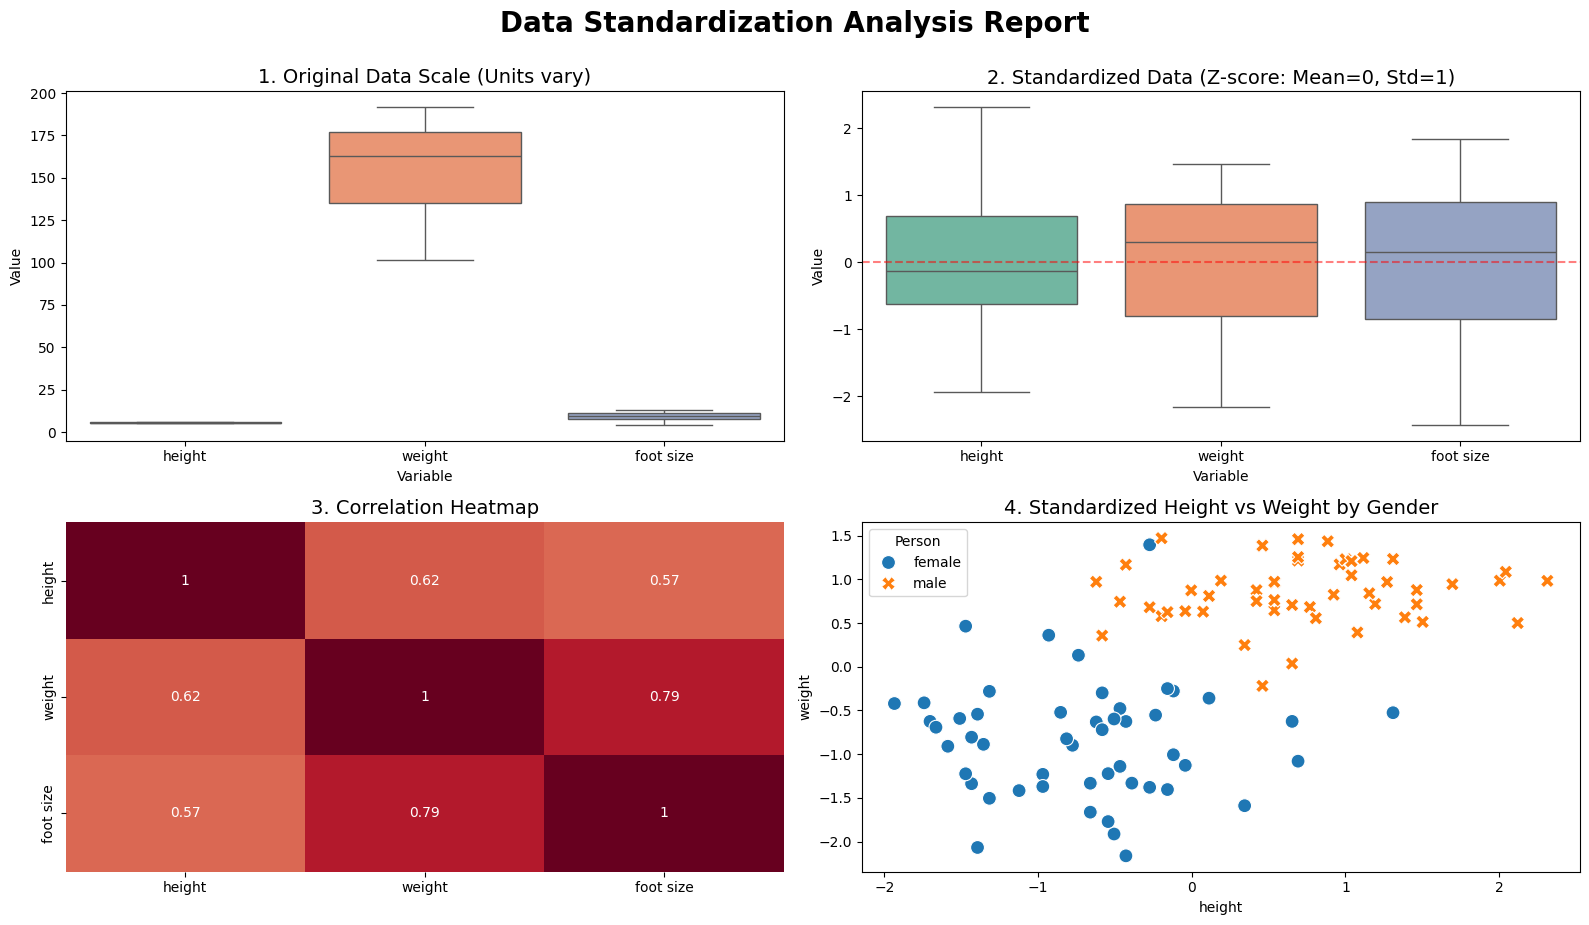


[ 표준화된 데이터 샘플 ]


,Person,height,weight,foot size
0,female,0.343741,-1.589367,-1.163012
1,female,-1.394276,-2.067093,-1.566102
2,female,-0.621824,-0.631494,-1.158213
3,female,-0.119730,-1.006331,-1.110226
4,male,2.004513,0.984059,1.202745


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# 1. 데이터 준비 및 표준화
df = pd.read_csv('human_data.csv')
cols = ['height', 'weight', 'foot size']
df_std = df.copy()
for col in cols:
    df_std[col] = (df[col] - df[col].mean()) / df[col].std()

# 2. 대시보드 설정 (크기 및 레이아웃)
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig)
plt.suptitle('Data Standardization Analysis Report', fontsize=20, fontweight='bold', y=0.95)

# [그래프 1] 원본 vs 표준화 박스플롯 비교 (척도 차이 시각화)
ax1 = fig.add_subplot(gs[0, 0])
df_melted = df[cols].melt(var_name='Variable', value_name='Value')
sns.boxplot(x='Variable', y='Value', data=df_melted, ax=ax1, palette='Set2')
ax1.set_title('1. Original Data Scale (Units vary)', fontsize=14)

ax2 = fig.add_subplot(gs[0, 1])
df_std_melted = df_std[cols].melt(var_name='Variable', value_name='Value')
sns.boxplot(x='Variable', y='Value', data=df_std_melted, ax=ax2, palette='Set2')
ax2.set_title('2. Standardized Data (Z-score: Mean=0, Std=1)', fontsize=14)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)

# [그래프 2] 상관계수 히트맵
ax3 = fig.add_subplot(gs[1, 0])
sns.heatmap(df[cols].corr(), annot=True, cmap='RdBu_r', center=0, ax=ax3, cbar=False)
ax3.set_title('3. Correlation Heatmap', fontsize=14)

# [그래프 3] 성별에 따른 분포 (Pairplot 대용 산점도)
ax4 = fig.add_subplot(gs[1, 1])
sns.scatterplot(data=df_std, x='height', y='weight', hue='Person', style='Person', s=100, ax=ax4)
ax4.set_title('4. Standardized Height vs Weight by Gender', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 요약 데이터 출력
print("\n[ 표준화된 데이터 샘플 ]")
display(df_std.head())

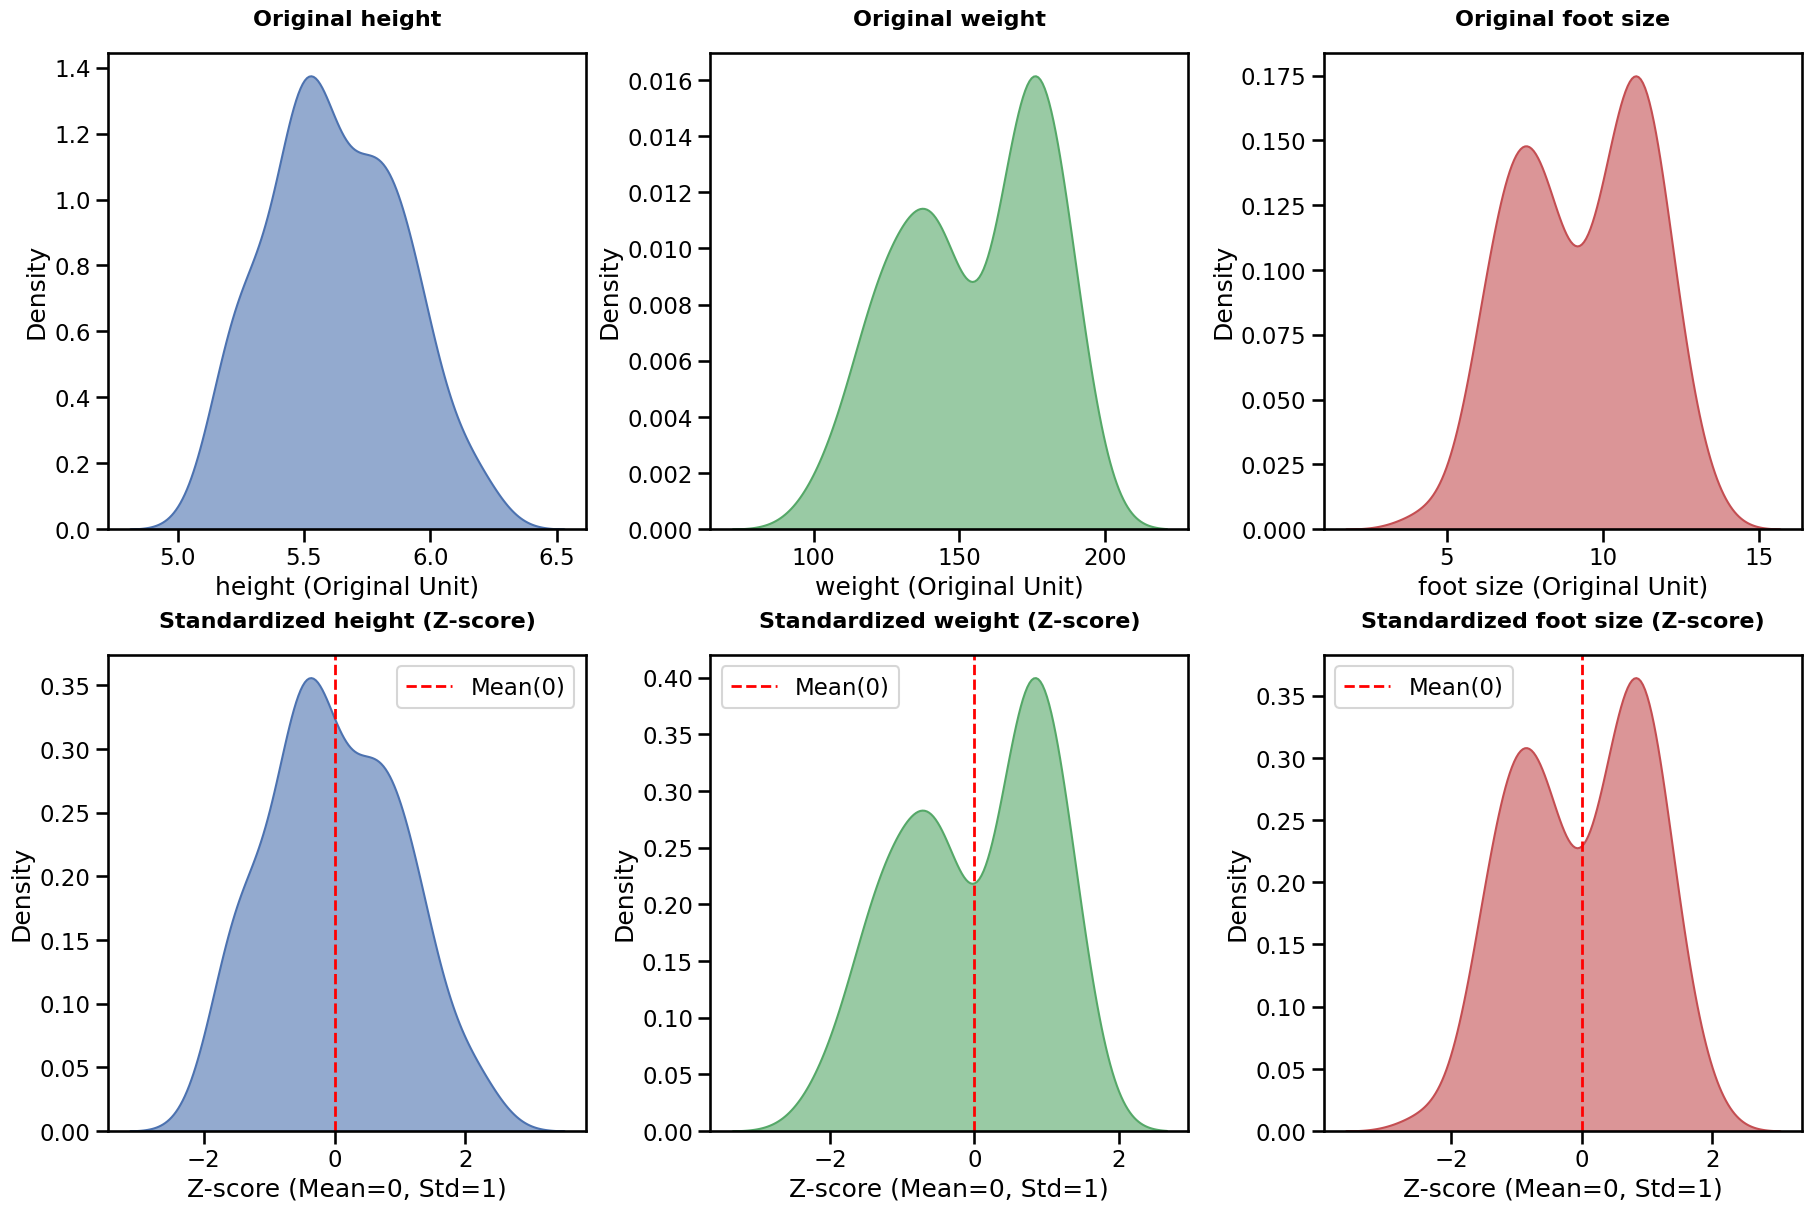

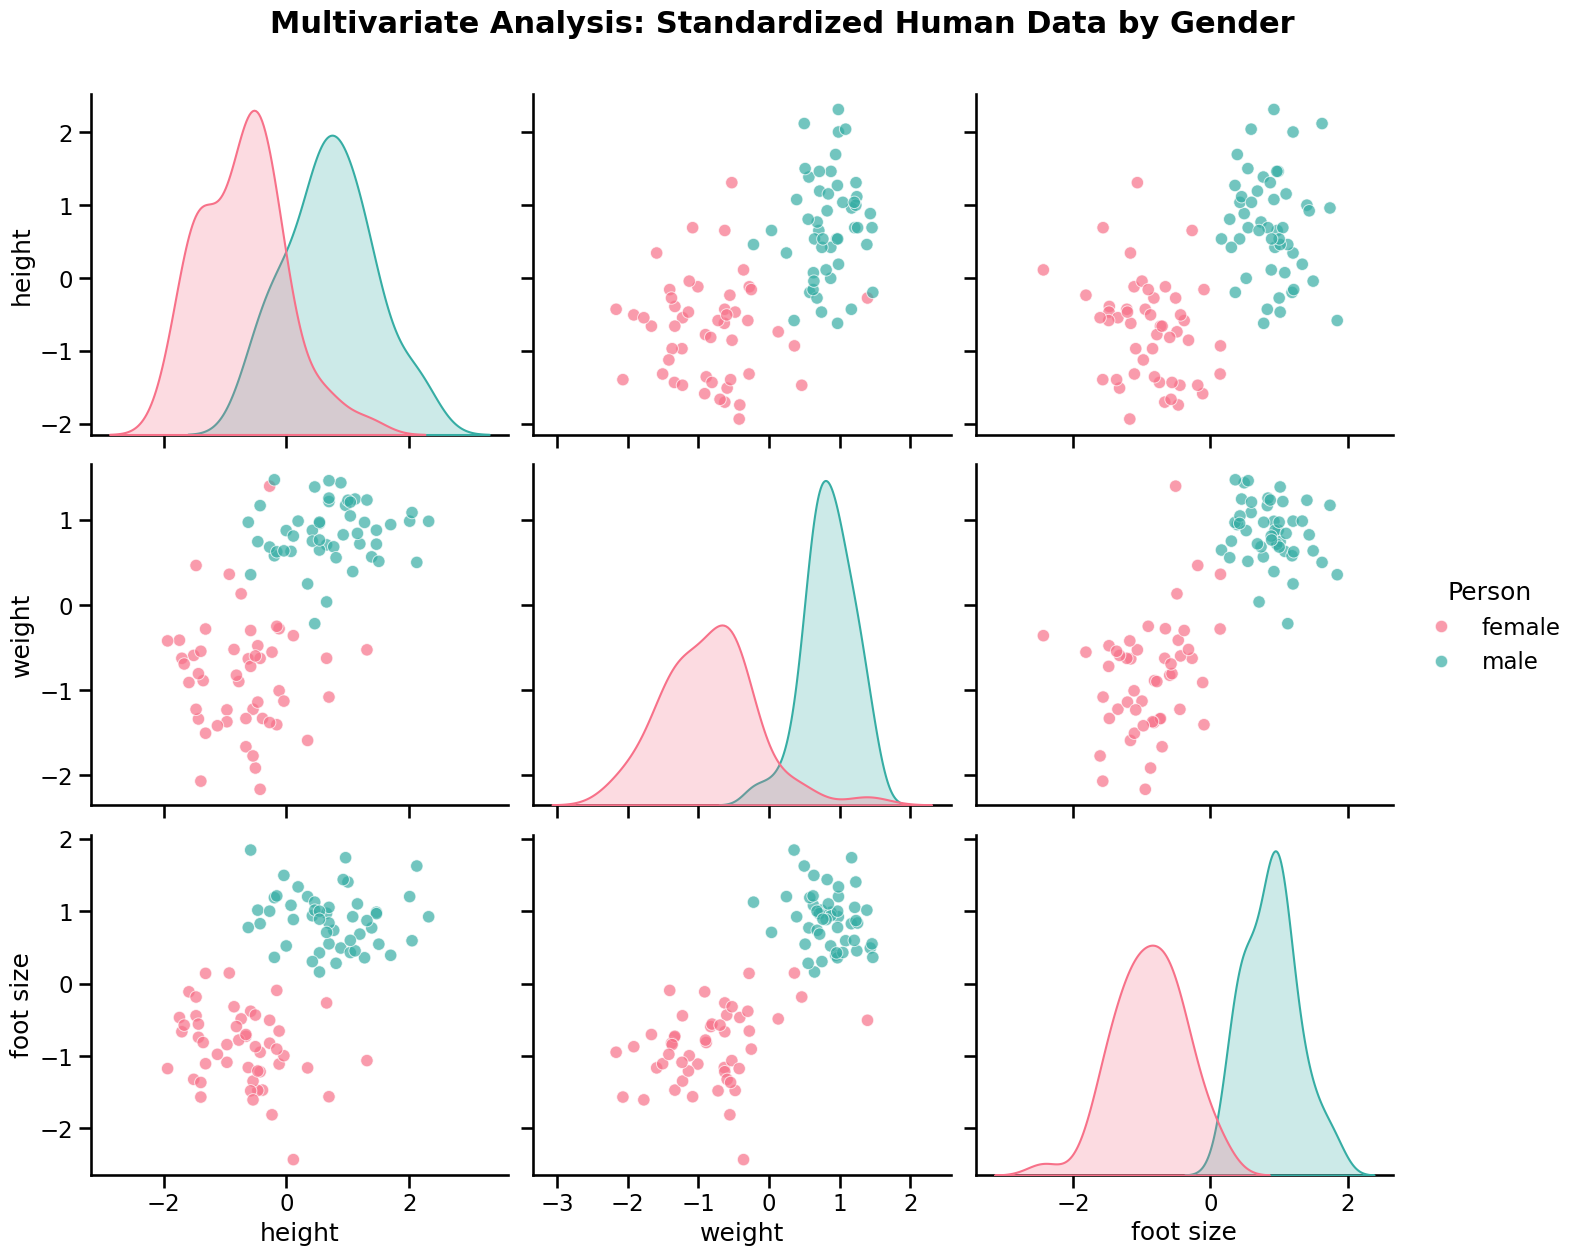

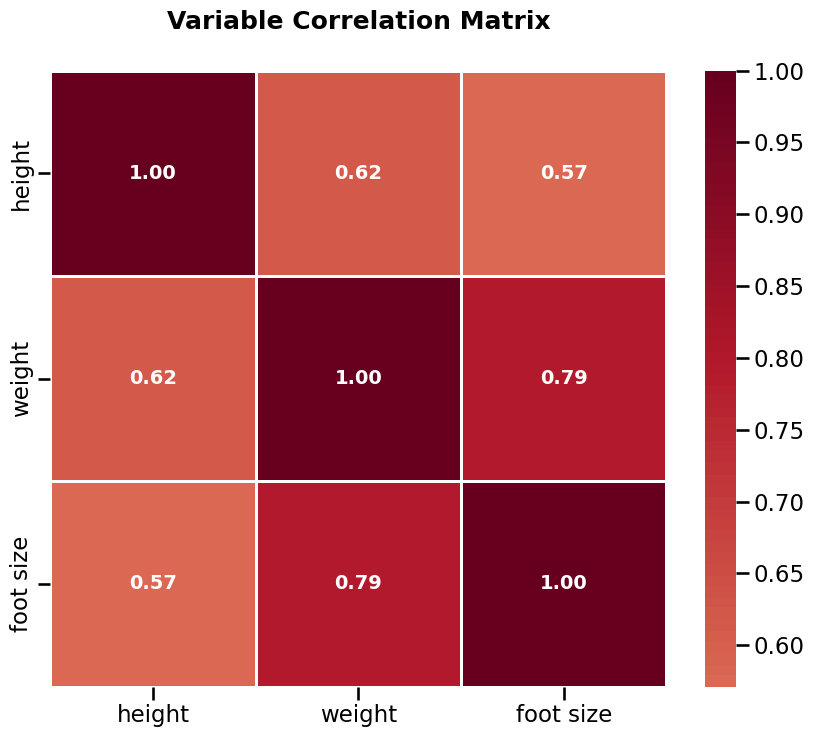

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 표준화
df = pd.read_csv('human_data.csv')
cols = ['height', 'weight', 'foot size']

# Z-score 표준화 수행
df_std = df.copy()
for col in cols:
    df_std[col] = (df[col] - df[col].mean()) / df[col].std()

# --- [그래프 1] 분포의 변화 (KDE Plot) ---
# 레이아웃 겹침 방지를 위해 constrained_layout=True를 사용합니다.
fig1, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

colors = ['#4C72B0', '#55A868', '#C44E52']

for i, col in enumerate(cols):
    # 상단: 원본 데이터 분포
    sns.kdeplot(data=df, x=col, fill=True, color=colors[i], alpha=0.6, ax=axes[0, i])
    axes[0, i].set_title(f'Original {col}', fontsize=16, fontweight='bold', pad=20)
    axes[0, i].set_xlabel(f'{col} (Original Unit)')

    # 하단: 표준화 데이터 분포 (평균 0 지점 표시)
    sns.kdeplot(data=df_std, x=col, fill=True, color=colors[i], alpha=0.6, ax=axes[1, i])
    axes[1, i].set_title(f'Standardized {col} (Z-score)', fontsize=16, fontweight='bold', pad=20)
    axes[1, i].set_xlabel('Z-score (Mean=0, Std=1)')
    axes[1, i].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean(0)')
    axes[1, i].legend()

plt.show()

# --- [그래프 2] 다변량 상관관계 분석 (Pair Plot) ---
sns.set_context("talk")
pp = sns.pairplot(df_std, hue='Person', palette='husl',
                 diag_kind='kde', height=4, aspect=1.2,
                 plot_kws={'alpha': 0.7, 's': 80, 'edgecolor': 'w'})
pp.fig.suptitle('Multivariate Analysis: Standardized Human Data by Gender', y=1.05, fontsize=22, fontweight='bold')
plt.show()

# --- [그래프 3] 상관관계 히트맵 ---
# 변수 간의 수치적 관계를 확인하는 필수 과정입니다.
plt.figure(figsize=(10, 8))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=2, square=True,
            annot_kws={"size": 14, "weight": "bold"})
plt.title('Variable Correlation Matrix', fontsize=18, fontweight='bold', pad=30)
plt.show()

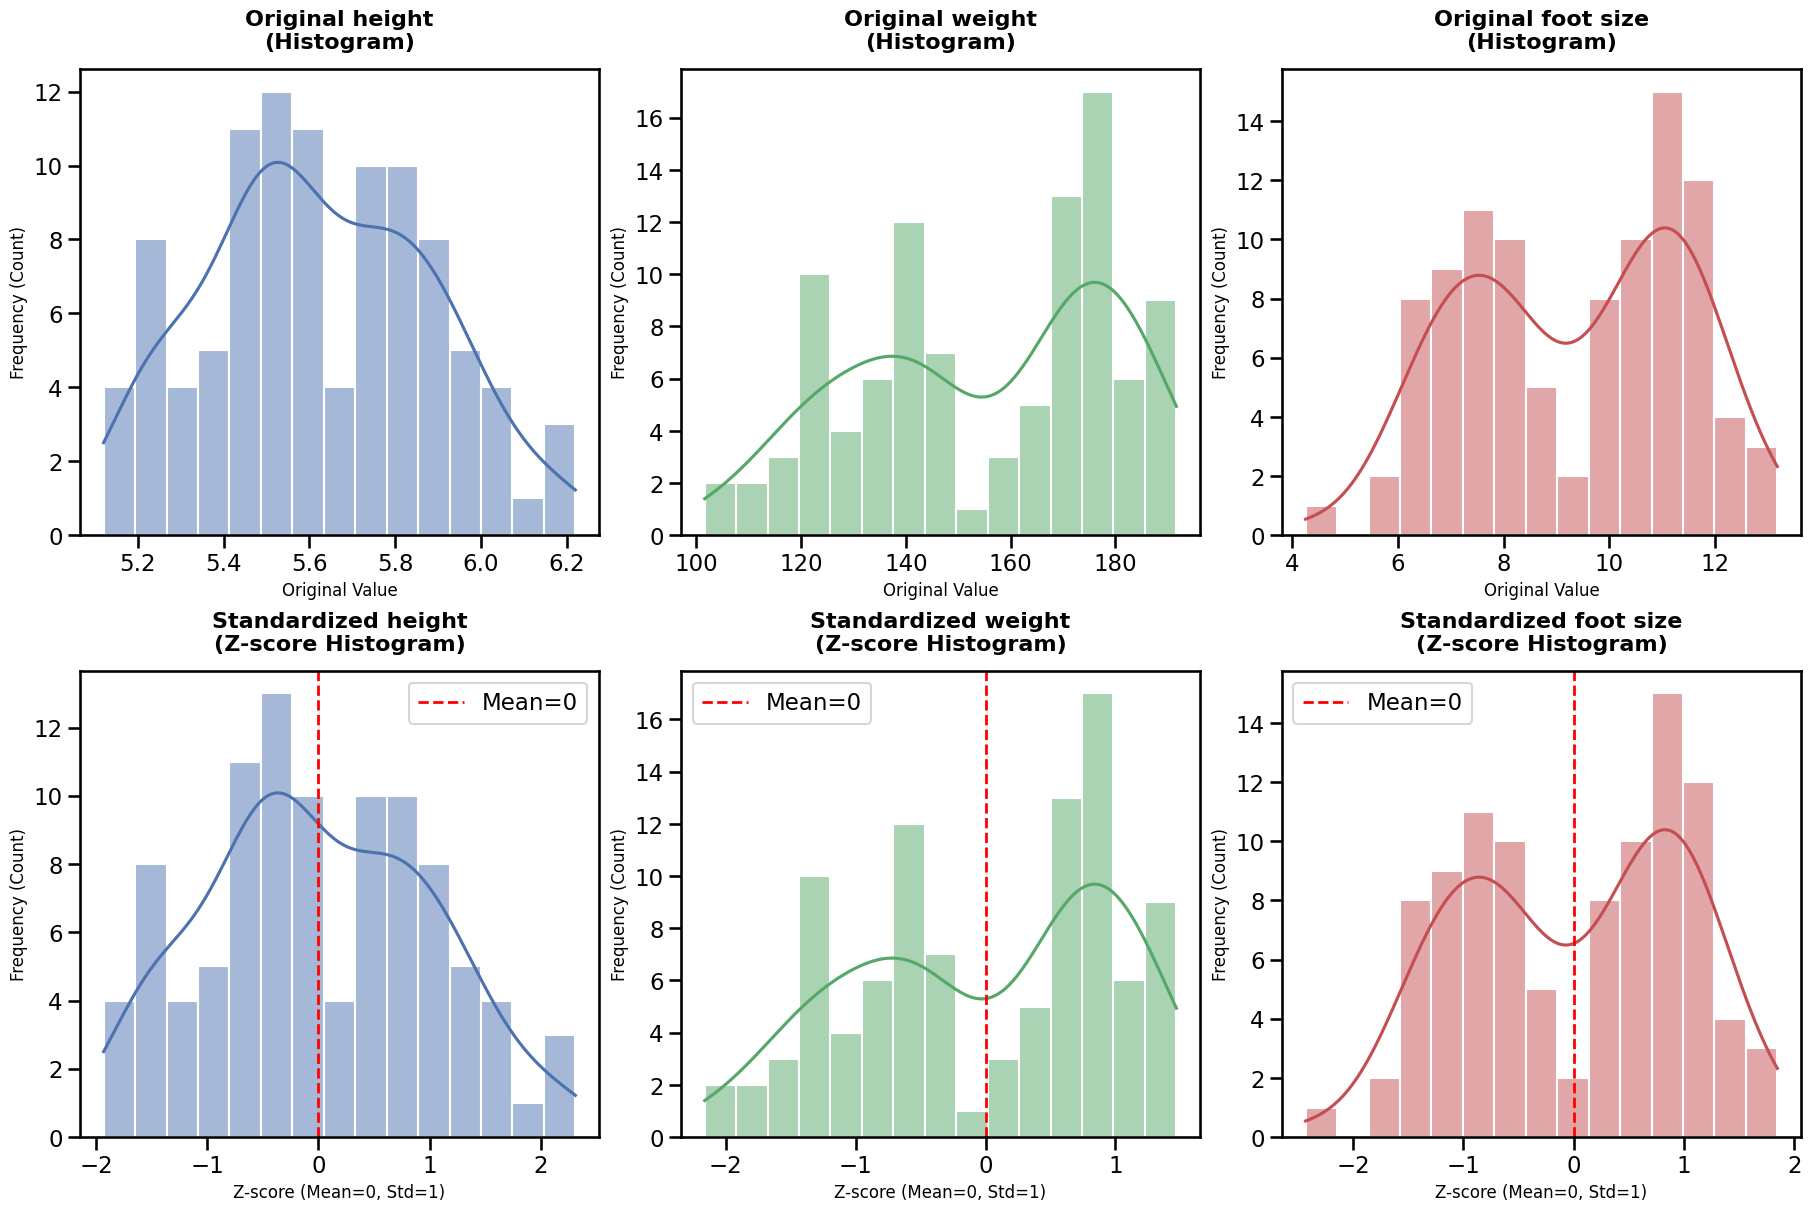

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 표준화
df = pd.read_csv('human_data.csv')
cols = ['height', 'weight', 'foot size']

df_std = df.copy()
for col in cols:
    df_std[col] = (df[col] - df[col].mean()) / df[col].std()

# 2. 히스토그램 시각화 레이아웃 설정 (글자 겹침 방지)
fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

# 색상 및 스타일 설정
colors = ['#4C72B0', '#55A868', '#C44E52']

for i, col in enumerate(cols):
    # --- 상단: 원본 데이터 히스토그램 ---
    sns.histplot(df[col], bins=15, kde=True, ax=axes[0, i], color=colors[i], alpha=0.5, edgecolor='w')
    axes[0, i].set_title(f'Original {col}\n(Histogram)', fontsize=16, fontweight='bold', pad=15)
    axes[0, i].set_xlabel('Original Value', fontsize=12)
    axes[0, i].set_ylabel('Frequency (Count)', fontsize=12)

    # --- 하단: 표준화 데이터 히스토그램 ---
    sns.histplot(df_std[col], bins=15, kde=True, ax=axes[1, i], color=colors[i], alpha=0.5, edgecolor='w')
    axes[1, i].set_title(f'Standardized {col}\n(Z-score Histogram)', fontsize=16, fontweight='bold', pad=15)
    axes[1, i].set_xlabel('Z-score (Mean=0, Std=1)', fontsize=12)
    axes[1, i].set_ylabel('Frequency (Count)', fontsize=12)

    # 평균(0) 지점에 빨간 점선 표시
    axes[1, i].axvline(0, color='red', linestyle='--', linewidth=2, label='Mean=0')
    axes[1, i].legend()

plt.show()

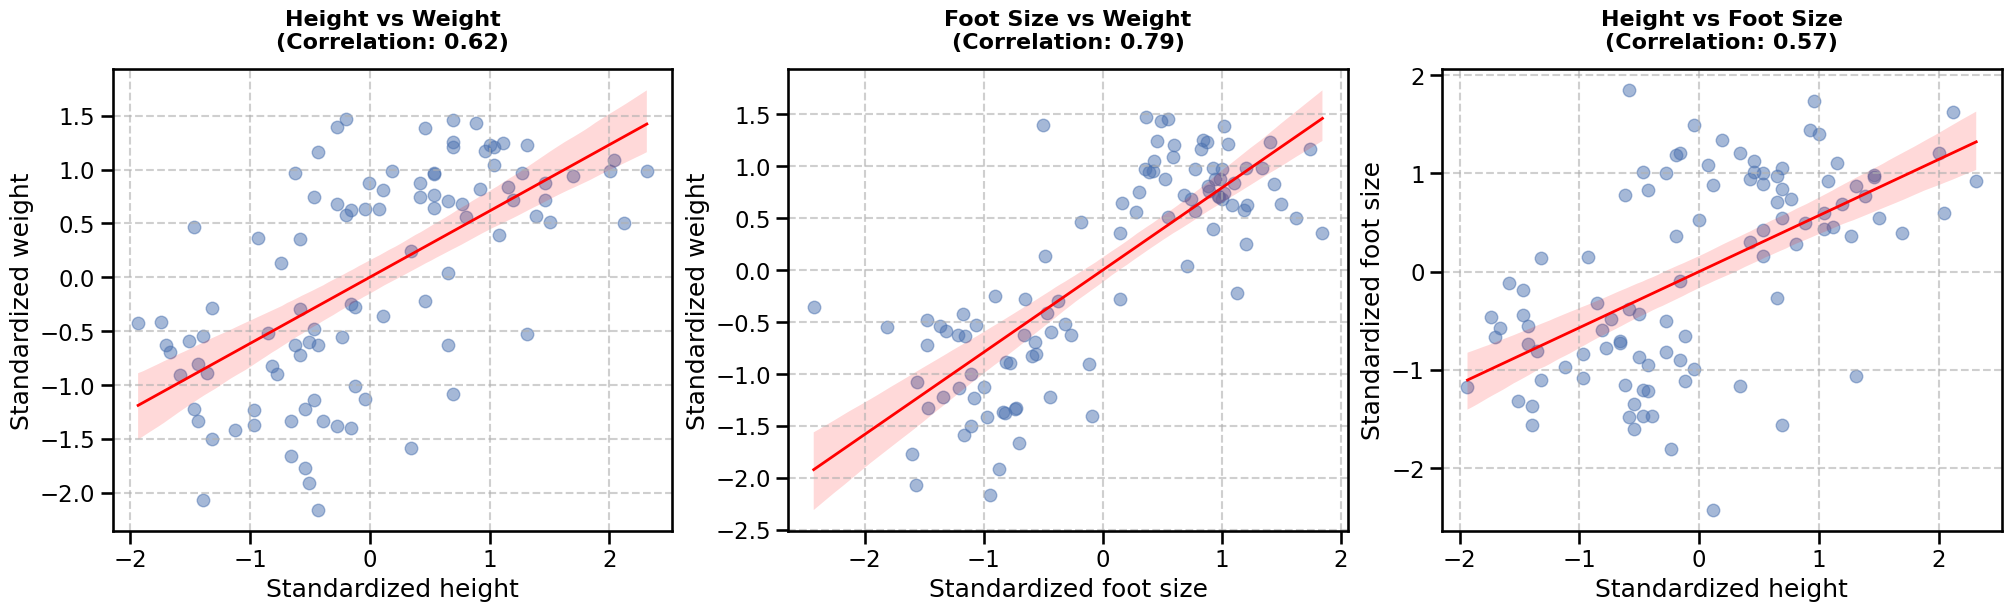

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 표준화
df = pd.read_csv('human_data.csv')
cols = ['height', 'weight', 'foot size']

# Z-score 표준화
df_std = df.copy()
for col in cols:
    df_std[col] = (df[col] - df[col].mean()) / df[col].std()

# 2. 연관성 분석 시각화 (1행 3열 구성)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

# 분석할 관계 쌍 정의
pairs = [
    ('height', 'weight', 'Height vs Weight'),
    ('foot size', 'weight', 'Foot Size vs Weight'),
    ('height', 'foot size', 'Height vs Foot Size')
]

for i, (x_col, y_col, title) in enumerate(pairs):
    # 산점도 + 회귀직선(Trend Line)
    sns.regplot(data=df_std, x=x_col, y=y_col, ax=axes[i],
                scatter_kws={'alpha':0.5, 'color':'#4C72B0'},
                line_kws={'color':'red', 'lw':2})

    # 상관계수 계산
    correlation = df_std[x_col].corr(df_std[y_col])

    axes[i].set_title(f'{title}\n(Correlation: {correlation:.2f})', fontsize=16, fontweight='bold', pad=15)
    axes[i].set_xlabel(f'Standardized {x_col}')
    axes[i].set_ylabel(f'Standardized {y_col}')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.show()